# FIFA World Cup 2026 Player Archetype Analysis

## Objective

This notebook analyzes the player archetypes discovered using K-Means clustering on PCA-engineered football performance indices.

The clustering was performed using four engineered dimensions:

- Attacking Impact Score
- Passing Impact Score
- Defensive Impact Score
- Movement Impact Score

The objective is to understand different statistical player profiles that emerged naturally from tournament data.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../data/processed/clustered_dataset.csv")

players = df[df["Position"] != "GK"].copy()

players.head()

,Player,Country,Position,Goals,Minutes Played,Assists,Attempts On Target,Attempts At Goal,Attempts At Goal Conv. Rate (%),Attempts Inside the Penalty Area,...,High Speed Running,Sprints,Total Distance (m),Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score,Goalkeeping Impact Score,Cluster,Player Archetype
0,Aaron Hickey,SCO,DF,0.0,79.0,0,0,0,0,0,...,103,30,8361.39,-1.324319,-0.451448,-0.396151,-1.862036,NaN,0,Balanced Contributors
1,Aaron Tshibola,COD,MF,0.0,0.0,0,0,0,0,0,...,0,0,0.00,-1.324319,-2.464258,-1.631957,-3.214255,NaN,2,Limited Tournament Impact
2,Aaron Wan Bissaka,COD,DF,0.0,399.0,0,0,0,0,0,...,460,194,40401.23,-1.324319,0.965554,1.302634,4.045113,NaN,3,Complete Midfielders
3,Abbosbek Fayzullaev,UZB,MF,1.0,240.0,0,2,3,33,2,...,341,141,25301.81,2.335252,0.623442,3.296770,1.925697,NaN,1,Dynamic Attackers
5,Abdallah Nasib,JOR,DF,0.0,287.0,0,0,0,0,0,...,269,86,26869.89,-1.324319,-1.092412,0.078532,-0.483015,NaN,0,Balanced Contributors


## Dataset Overview

The dataset contains:

- Outfield players only
- PCA-engineered football indices
- Cluster assignments
- Player archetypes

In [10]:
cluster_counts = players["Player Archetype"].value_counts()

cluster_counts

Player Archetype
Limited Tournament Impact     399
Balanced Contributors         334
Complete Midfielders          191
Dynamic Attackers              89
Elite All-Round Performers     70
Tournament Superstars          14
Name: count, dtype: int64

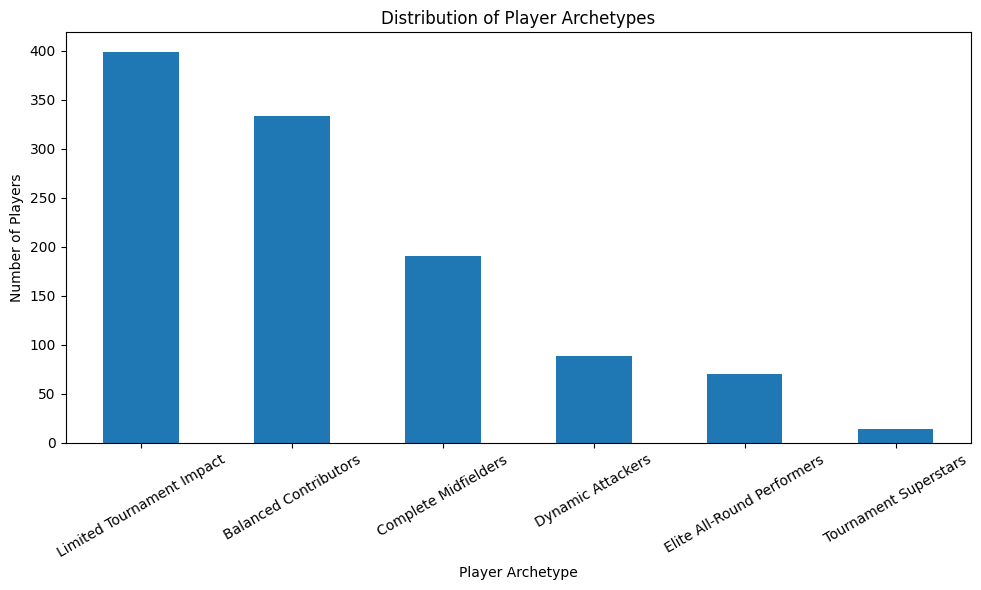

In [11]:
plt.figure(figsize=(10,6))

cluster_counts.plot(kind="bar")

plt.title("Distribution of Player Archetypes")

plt.xlabel("Player Archetype")

plt.ylabel("Number of Players")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

## Observation

This visualization shows how common each player archetype is throughout the tournament.

Large clusters represent common performance profiles, whereas smaller clusters indicate statistically unique player types.

In [12]:
summary = players.groupby("Player Archetype")[
    [
        "Attacking Impact Score",
        "Passing Impact Score",
        "Defensive Impact Score",
        "Movement Impact Score"
    ]
].mean()

summary

,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
Player Archetype,,,,
Balanced Contributors,-0.398685,0.233084,-0.111736,-0.125065
Complete Midfielders,0.084478,2.170632,1.775088,2.815166
Dynamic Attackers,3.543934,1.009680,1.448464,3.086478
Elite All-Round Performers,3.389488,4.118742,3.803306,7.211863
Limited Tournament Impact,-1.102761,-1.755705,-1.320618,-2.533777
Tournament Superstars,14.027082,4.536283,4.132584,8.630216


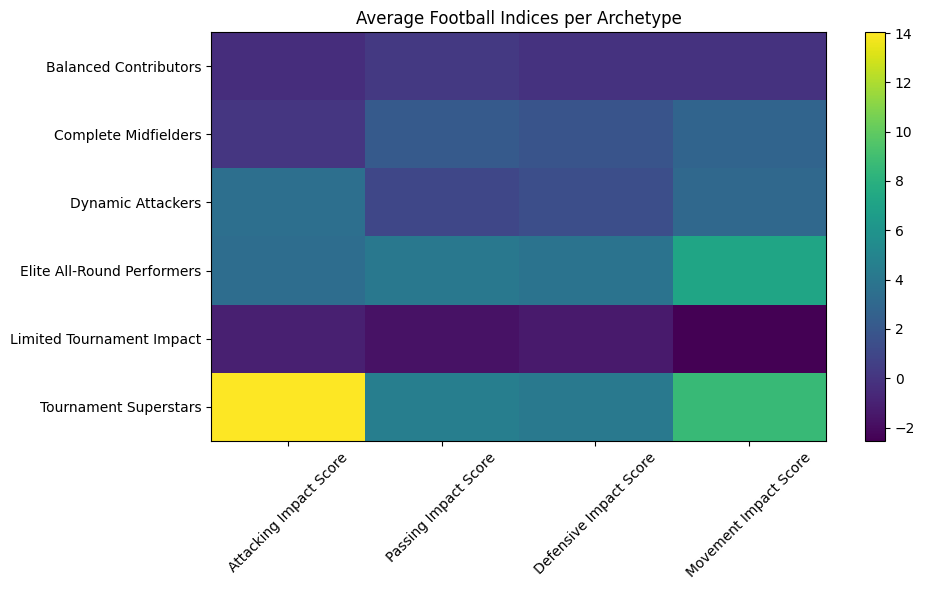

In [13]:
plt.figure(figsize=(10,6))

plt.imshow(summary, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(summary.columns)),
    summary.columns,
    rotation=45
)

plt.yticks(
    range(len(summary.index)),
    summary.index
)

plt.title("Average Football Indices per Archetype")

plt.tight_layout()

plt.show()

## Interpretation

Each archetype represents a statistically distinct performance profile.

The names are assigned purely from the average football indices of each cluster rather than player identity or playing position.

In [20]:
from sklearn.preprocessing import MinMaxScaler

FEATURES = [
    "Attacking Impact Score",
    "Passing Impact Score",
    "Defensive Impact Score",
    "Movement Impact Score"
]

# -------------------------------------------------------
# Normalize each football index
# -------------------------------------------------------

scaler = MinMaxScaler()

players_scaled = players.copy()

players_scaled[FEATURES] = scaler.fit_transform(
    players[FEATURES]
)

# -------------------------------------------------------
# Overall Performance Score
# -------------------------------------------------------

players["Overall Performance Score"] = (
    players_scaled[FEATURES]
    .sum(axis=1)
)

# -------------------------------------------------------
# Display Archetype Rankings
# -------------------------------------------------------

for archetype in sorted(players["Player Archetype"].unique()):

    print("=" * 90)
    print(archetype.upper())
    print("=" * 90)

    cluster = players[
        players["Player Archetype"] == archetype
    ].copy()

    # Cluster statistics
    print("\nCluster Statistics\n")

    print(cluster[FEATURES].mean().round(2))

    print("\nTop Performers\n")

    display(
        cluster
        .sort_values(
            "Overall Performance Score",
            ascending=False
        )
        [
            [
                "Player",
                "Country",
                "Position",
                "Overall Performance Score",
                "Attacking Impact Score",
                "Passing Impact Score",
                "Defensive Impact Score",
                "Movement Impact Score"
            ]
        ]
        .head(15)
    )

BALANCED CONTRIBUTORS

Cluster Statistics

Attacking Impact Score   -0.40
Passing Impact Score      0.23
Defensive Impact Score   -0.11
Movement Impact Score    -0.13
dtype: float64

Top Performers



,Player,Country,Position,Overall Performance Score,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
309,Dodi Lukebakio,BEL,FW,0.870437,1.474248,2.194795,0.013269,0.944957
849,Mohamed Kanno,KSA,MF,0.846923,0.638275,1.682593,0.784322,0.440120
511,Ivan Basic,BIH,MF,0.843470,0.731725,2.383681,0.120702,0.513587
477,Houssem Aouar,ALG,MF,0.841950,0.810072,0.993606,0.317785,1.951697
427,Giovanni Reyna,USA,MF,0.840941,1.119183,1.430218,0.089975,1.547541
364,Esmir Bajraktarevic,BIH,FW,0.836467,0.200359,-0.500074,1.143852,2.824434
898,Nathanael Mbuku,COD,MF,0.828480,0.494416,1.060596,1.353573,0.078490
617,Juan Quintero,COL,MF,0.826152,0.778545,3.690673,-0.774300,-0.034273
1096,Seol Youngwoo,KOR,DF,0.825200,-0.720379,1.319107,-0.090063,2.873969
12,Abdulkerim Bardakci,TUR,DF,0.820446,-0.384477,2.924756,0.109468,0.114721


COMPLETE MIDFIELDERS

Cluster Statistics

Attacking Impact Score    0.08
Passing Impact Score      2.17
Defensive Impact Score    1.78
Movement Impact Score     2.82
dtype: float64

Top Performers



,Player,Country,Position,Overall Performance Score,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
161,Ayyoub Bouaddi,MAR,MF,1.518734,-0.301048,2.766364,4.303166,5.111740
1029,Richie Laryea,CAN,DF,1.514879,-0.233455,3.094345,4.575741,4.107750
868,Moises Caicedo,ECU,MF,1.499800,1.003599,4.790689,2.697664,4.002607
110,Andres Cubas,PAR,MF,1.463839,-1.003983,0.118973,7.634344,2.497032
752,Manuel Akanji,SUI,DF,1.451832,-0.662749,5.937070,1.772031,4.261223
283,Dayot Upamecano,FRA,DF,1.451311,0.651626,4.548260,2.315439,4.361123
865,Mohanad Lashin,EGY,MF,1.448770,-0.405165,2.862504,4.633046,3.296460
219,Casemiro,BRA,MF,1.443567,2.253000,3.204756,3.389477,3.202371
53,Alex Freeman,USA,DF,1.439039,2.677662,4.702235,1.540523,3.997264
1027,Ricardo Rodriguez,SUI,DF,1.434749,-0.346149,5.225740,1.858093,4.571775


DYNAMIC ATTACKERS

Cluster Statistics

Attacking Impact Score    3.54
Passing Impact Score      1.01
Defensive Impact Score    1.45
Movement Impact Score     3.09
dtype: float64

Top Performers



...

,Player,Country,Position,Overall Performance Score,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
17,Achraf Hakimi,MAR,DF,2.651152,7.289795,8.505980,5.183286,10.624444
1038,Rodri,ESP,MF,2.555472,0.847231,7.963476,5.095292,13.864160
341,Elliot Anderson,ENG,MF,2.438060,2.349418,7.290271,6.122882,10.082537
986,Pedri,ESP,MF,2.374418,0.898519,5.727891,6.734234,10.938983
202,Bruno Fernandes,POR,MF,2.303589,3.657582,7.118456,5.395931,8.429486
436,Granit Xhaka,SUI,MF,2.277407,3.482250,6.517376,4.571652,10.282459
902,Neil El Aynaoui,MAR,MF,2.268841,2.665673,3.284711,7.169722,10.545676
352,Enzo Fernandez,ARG,MF,2.265142,5.767386,7.916184,3.004234,9.443963
728,Luis Diaz,COL,FW,2.219549,8.102361,5.093798,3.542592,10.051811
166,Azzedine Ounahi,MAR,MF,2.159907,3.261537,5.484224,4.444883,9.999048


LIMITED TOURNAMENT IMPACT

Cluster Statistics

Attacking Impact Score   -1.10
Passing Impact Score     -1.76
Defensive Impact Score   -1.32
Movement Impact Score    -2.53
dtype: float64

Top Performers



,Player,Country,Position,Overall Performance Score,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
462,Hassan Alhaydos,QAT,FW,0.387440,1.540718,-1.700824,-0.390047,-1.490785
1083,Santiago Gimenez,MEX,FW,0.361898,-0.262405,-1.942893,-0.444869,-0.392107
943,Odiljon Xamrobekov,UZB,MF,0.361550,-0.923974,-1.322434,-0.221966,-1.187384
269,Danilo Santos,BRA,MF,0.353308,-0.133976,-0.642680,-1.079483,-1.272664
679,Kristian Thorstvedt,NOR,MF,0.352694,-0.089940,-1.362790,-0.730850,-0.943496
158,Ayoub El Kaabi,MAR,FW,0.352231,0.235727,-1.728821,-0.627088,-0.843161
77,Ali Azaizeh,JOR,FW,0.346344,-0.389476,-1.457979,-0.567358,-1.015645
821,Meschack Elia,COD,FW,0.345655,0.223748,-0.564182,-1.107832,-1.682051
1094,Seko Fofana,CIV,MF,0.343640,0.756504,-1.259704,-1.073143,-1.182702
724,Lucas Herrington,AUS,DF,0.337799,-1.324319,-0.820613,-1.014429,-0.671285


TOURNAMENT SUPERSTARS

Cluster Statistics

Attacking Impact Score    14.03
Passing Impact Score       4.54
Defensive Impact Score     4.13
Movement Impact Score      8.63
dtype: float64

Top Performers



,Player,Country,Position,Overall Performance Score,Attacking Impact Score,Passing Impact Score,Defensive Impact Score,Movement Impact Score
711,Lionel Messi,ARG,FW,3.252666,26.150583,10.397399,4.915753,7.114059
684,Kylian Mbappe,FRA,FW,3.129671,22.821765,8.096425,3.327993,12.821282
825,Michael Olise,FRA,FW,3.021589,9.824215,7.943227,7.199528,12.715452
688,Lamine Yamal,ESP,FW,2.784138,10.767412,9.670189,3.567512,11.918605
618,Jude Bellingham,ENG,MF,2.781443,13.699736,5.538166,4.675529,13.664093
963,Ousmane Dembele,FRA,FW,2.579855,12.246201,7.840011,4.004767,9.201839
1185,Vinicius Junior,BRA,FW,2.497309,11.825980,6.670943,4.106078,9.434442
835,Mikel Oyarzabal,ESP,FW,2.412090,15.443509,1.331503,5.774870,10.000226
581,Jonathan David,CAN,FW,2.114572,9.887634,1.607392,5.841414,7.893824
460,Harry Kane,ENG,FW,2.110494,15.792510,1.915663,5.021327,5.130264
